In [99]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder, MultiLabelBinarizer
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("whitegrid")
from sklearn.feature_extraction.text import TfidfVectorizer
import json

In [2]:
df = pd.read_csv("youtube_videos.csv")

In [4]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


# Min Max Scaler

In [5]:
df["subscribers"]

,subscribers
0,441016
1,25339
2,2398429
3,498144
4,30039
...,...
205,13428
206,10005
207,483919
208,11937


In [6]:
scaler = MinMaxScaler()

In [7]:
df["subscribers_minmax"]=scaler.fit_transform(df[["subscribers"]])  #column should be fed as vectors, inside square brackets

In [8]:
df["subscribers_minmax"]

,subscribers_minmax
0,0.056122
1,0.002541
2,0.308431
3,0.063485
4,0.003147
...,...
205,0.001006
206,0.000565
207,0.061652
208,0.000814


In [9]:
df["subscribers_minmax"].describe()  #how to check it worked

,subscribers_minmax
count,210.000000
mean,0.128853
std,0.265999
min,0.000000
25%,0.002555
50%,0.016794
75%,0.061946
max,1.000000


In [10]:
df["views_minmax"]=scaler.fit_transform(df[["views"]])  #column should be fed as vectors, inside square brackets

In [11]:
df["views_minmax"]

,views_minmax
0,0.032213
1,0.003363
2,0.187937
3,0.026480
4,0.001587
...,...
205,0.000715
206,0.000475
207,0.014699
208,0.000229


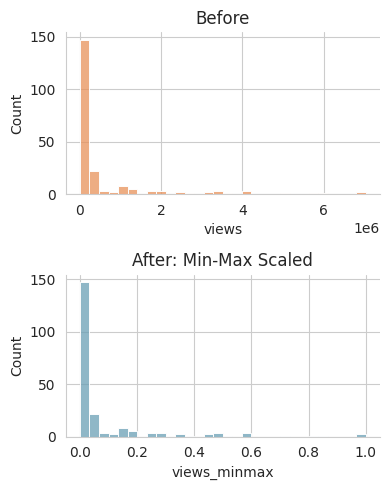

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))


#before graph
sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("views")

#after scaling graph
sns.histplot(df["views_minmax"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("views_minmax")

sns.despine()
plt.tight_layout()
plt.show()

# Standard Scaler

In [13]:
standard_scalar = StandardScaler()

In [14]:
df["view_zscore"] = standard_scalar.fit_transform(df[["views"]])

In [15]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [16]:
df["likes_zscore"] = standard_scalar.fit_transform(df[["likes"]])

In [17]:
df[["likes", "likes_zscore"]].describe()

,likes,likes_zscore
count,210.000000,2.100000e+02
mean,25765.304762,8.458842e-18
std,66234.880530,1.002389e+00
min,33.000000,-3.894291e-01
25%,488.750000,-3.825319e-01
50%,2204.000000,-3.565735e-01
75%,12510.750000,-2.005926e-01
max,455256.000000,6.499853e+00


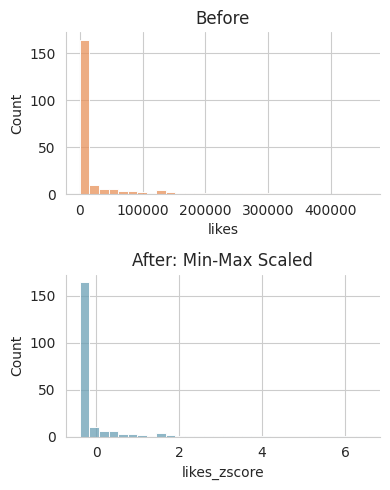

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))


#before graph
sns.histplot(df["likes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("likes")

#after scaling graph
sns.histplot(df["likes_zscore"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("likes_zscore")

sns.despine()
plt.tight_layout()
plt.show()

# Robust Scaler

In [19]:
robust_scaler = RobustScaler()

In [20]:
df["view_robust"] = robust_scaler.fit_transform(df[["views"]])

In [21]:
df[["views", "view_robust"]].describe()

,views,view_robust
count,2.100000e+02,210.000000
mean,5.485440e+05,1.608176
std,1.223751e+06,4.078175
min,1.412000e+03,-0.215152
25%,1.080400e+04,-0.183853
50%,6.597350e+04,0.000000
75%,3.108772e+05,0.816147
max,7.038551e+06,23.236251


In [22]:
df["shares_robust"] = robust_scaler.fit_transform(df[["shares"]])

In [23]:
df[["shares", "shares_robust"]].describe()

,shares,shares_robust
count,210.000000,210.000000
mean,3947.052381,1.658617
std,8731.782974,4.009543
min,5.000000,-0.151533
25%,65.500000,-0.123752
50%,335.000000,0.000000
75%,2243.250000,0.876248
max,48004.000000,21.889106


# Log Transform

In [24]:
df["views_log"] = np.log1p(df["views"])

In [25]:
df["views_log"]

,views_log
0,12.337553
1,10.129786
2,14.096130
3,12.142883
4,9.440181
...,...
205,8.770594
206,8.467162
207,11.560315
208,8.015327


<Axes: xlabel='views_log', ylabel='Count'>

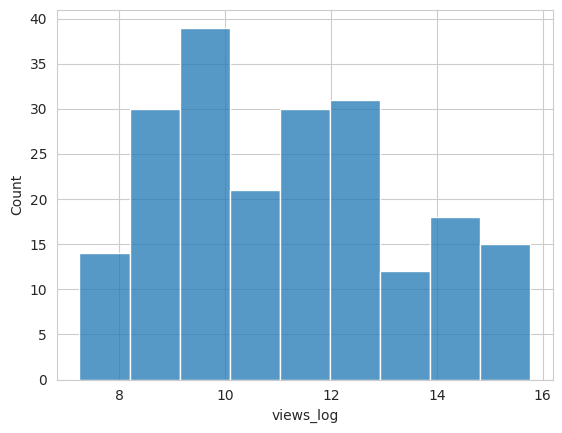

In [26]:
sns.histplot(df["views_log"])

<Axes: xlabel='views', ylabel='Count'>

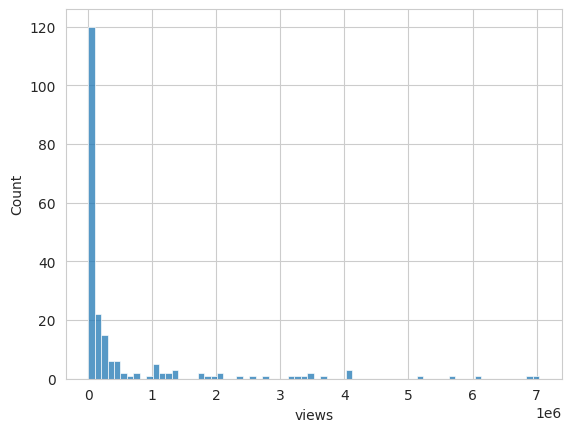

In [27]:
sns.histplot(df["views"])

In [28]:
df["watch_time_minutes_log"] = np.log1p(df["watch_time_minutes"])

In [30]:
df["watch_time_minutes_log"]

,watch_time_minutes_log
0,13.902686
1,12.957062
2,16.376810
3,14.517783
4,12.478258
...,...
205,11.380513
206,11.793190
207,14.633770
208,11.488008


<Axes: xlabel='watch_time_minutes_log', ylabel='Count'>

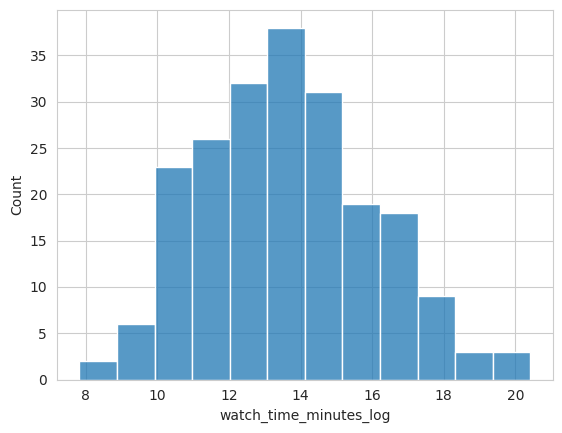

In [31]:
sns.histplot(df["watch_time_minutes_log"])

<Axes: xlabel='watch_time_minutes', ylabel='Count'>

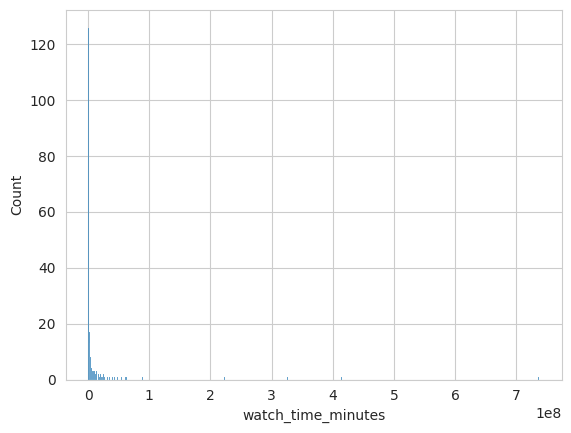

In [32]:
sns.histplot(df["watch_time_minutes"])

# Binning

In [37]:
bins = [0, 300, 2000, float("inf")]
labels = ['short', 'medium', 'long']

df["duration_bins"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

<Axes: xlabel='duration_bins', ylabel='count'>

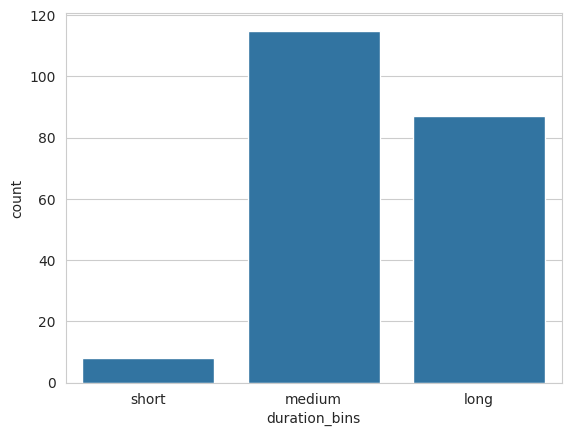

In [40]:
sns.countplot(x=df["duration_bins"], data=df)

In [49]:
bins = [0, 1000, 10000, 50000, float("inf")]
labels = ["not popular", "kinda popular", "popular", "viral"]


df["likes_bins"] = pd.cut(df["likes"], bins=bins, labels=labels)

<Axes: xlabel='likes_bins', ylabel='count'>

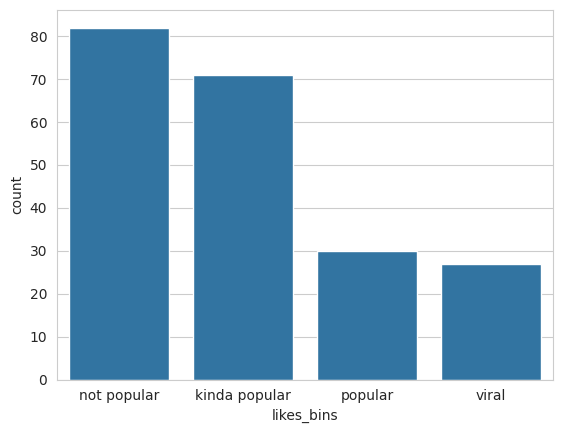

In [50]:
sns.countplot(x=df["likes_bins"], data=df)

# Ordinal Encoder (Strings)

In [57]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [56]:
encoder = OrdinalEncoder(categories = [['Small', 'Mid', 'Large']])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [59]:
df[['channel_tier', 'channel_tier_encoded']]

,channel_tier,channel_tier_encoded
0,Mid,1
1,Small,0
2,Large,2
3,Mid,1
4,Small,0
...,...,...
205,Small,0
206,Small,0
207,Mid,1
208,Small,0


# One Hot Encoding

In [60]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [61]:
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [62]:
df = pd.concat([df, dummyVars], axis=1)

In [63]:
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,duration_bin,duration_bins,likes_bins,channel_tier_encoded,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,medium,medium,kinda popular,1,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,medium,medium,not popular,0,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,medium,medium,kinda popular,2,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,medium,medium,kinda popular,1,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,long,long,not popular,0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,medium,medium,not popular,0,False,True,False,False,False,False
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,long,long,not popular,0,False,False,False,False,True,False
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,long,long,not popular,1,False,False,True,False,False,False
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,long,long,not popular,0,True,False,False,False,False,False


# How to Create Time Stamp

In [64]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [65]:
df["uploaded_at"]

,uploaded_at
0,2024-01-07 00:05:00
1,2024-01-06 21:46:00
2,2024-01-08 18:39:00
3,2024-01-04 14:26:00
4,2024-01-08 04:25:00
...,...
205,2024-01-05 13:15:00
206,2024-01-06 08:45:00
207,2024-01-07 20:58:00
208,2024-01-04 21:15:00


In [66]:
df["uploaded_at"].dt.day_of_week

,uploaded_at
0,6
1,5
2,0
3,3
4,0
...,...
205,4
206,5
207,6
208,3


# All Caps Count

In [78]:
df['caps_count'] = df['title'].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

df['lower_count'] = df['title'].apply(
    lambda t: sum(1 for w in t.split() if w.islower())
)

In [80]:
df[['caps_count', 'lower_count']]

,caps_count,lower_count
0,3,6
1,1,6
2,0,7
3,0,3
4,4,5
...,...,...
205,3,6
206,2,9
207,0,4
208,2,9


## Alternate

In [75]:
def countCaps(t):
  sum=0
  words = t.split()
  for word in words:
    if word.isupper():
      sum = sum+1
  return sum

In [76]:
df['caps_count'] = df['title'].apply(
    countCaps
)

In [77]:
df['caps_count']

,caps_count
0,3
1,1
2,0
3,0
4,4
...,...
205,3
206,2
207,0
208,2


# TF-IDF

In [88]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")

In [89]:
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

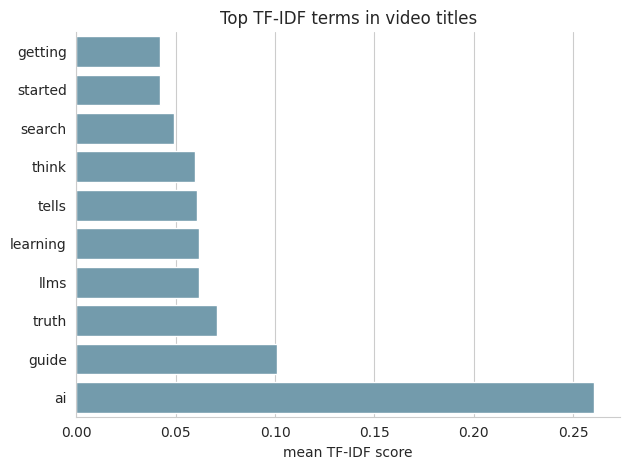

In [90]:
sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

# Retention Rate

In [93]:
df['duration_minutes'] = df['duration_seconds'] / 60
df['retention_rate'] = df['watch_time_minutes'] / (df['views'] * df['duration_minutes'])

In [94]:
df['retention_rate']

,retention_rate
0,0.398058
1,0.535375
2,0.415428
3,0.483146
4,0.396453
...,...
205,0.469772
206,0.289126
207,0.495605
208,0.528993


# Interaction Features

In [95]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

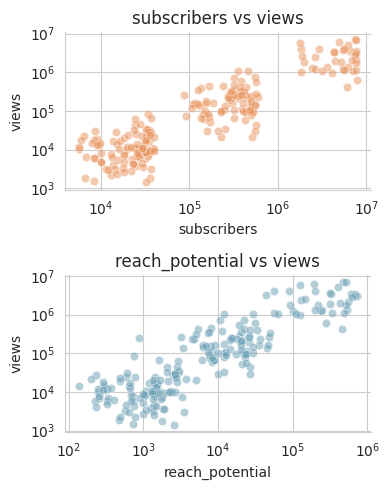

In [96]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

# Multi-Label Encoding

In [100]:
df["hashtags"] = df["hashtags"].apply(json.loads)

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

In [101]:
result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
